
# Direction J: Ensemble pangenome feature selection

## Mục tiêu
- Dùng ma trận gen phụ đầy đủ.
- Chọn đặc trưng bằng nhiều tiêu chí: chi-square, L1 Logistic, Random Forest, ensemble ranking.
- Thử k = 50, 200, 500.
- Tối ưu model/threshold theo từng thuốc.
- So sánh với 50 đặc trưng có sẵn của bài báo.


In [ ]:

# =========================
# 0. Import
# =========================

import os
import re
import json
import math
import shutil
import subprocess
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

print("HAS_XGB:", HAS_XGB)


In [ ]:

# =========================
# 1. Cấu hình
# =========================

REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"

BASE_DIR = Path("/content/salmonella_direction_J_fixed")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
EXTRACT_DIR = BASE_DIR / "extracted"
OUTPUT_DIR = BASE_DIR / "outputs"

for d in [BASE_DIR, EXTRACT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

# Để chạy nhanh trước. Muốn chắc hơn thì tăng lên 10 hoặc 20.
N_REPEATS = 3
RANDOM_SEEDS = list(range(42, 42 + N_REPEATS))

# Số lượng đặc trưng thử
K_LIST = [50, 200, 500]

# Prefilter theo phương sai để tránh quá chậm
MAX_CANDIDATE_FEATURES = 5000

# Selector
ENABLE_SELECTOR_CHI2 = True
ENABLE_SELECTOR_L1 = True
ENABLE_SELECTOR_RF = True
ENABLE_SELECTOR_MI = False
ENABLE_SELECTOR_XGB = False

# Model
MODEL_NAMES = ["LR_balanced", "RF_balanced"]
if HAS_XGB:
    MODEL_NAMES.append("XGB_weighted")

THRESHOLD_METRIC = "f1"

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("N_REPEATS:", N_REPEATS)
print("K_LIST:", K_LIST)
print("MODEL_NAMES:", MODEL_NAMES)


In [ ]:

# =========================
# 2. Clone repo và giải nén ma trận gen phụ
# =========================

if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git "{REPO_DIR}"
else:
    print("Repo đã tồn tại:", REPO_DIR)

!apt-get update -qq
!apt-get install -y unrar > /dev/null

accessory_extract_dir = EXTRACT_DIR / "accessory_gene"
accessory_extract_dir.mkdir(parents=True, exist_ok=True)

accessory_rar = REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar"

if not any(accessory_extract_dir.glob("*")):
    if accessory_rar.exists():
        print("Giải nén:", accessory_rar)
        !unrar x -o+ "{accessory_rar}" "{accessory_extract_dir}/" > /dev/null
    else:
        print("Không thấy RAR trong repo, tải trực tiếp.")
        local_rar = BASE_DIR / "accessory_gene_existence_matrix.rar"
        url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/Roary/accessory%20gene%20existence%20matrix.rar"
        !wget -q -O "{local_rar}" "{url}"
        !unrar x -o+ "{local_rar}" "{accessory_extract_dir}/" > /dev/null

print("File accessory:")
!find "{accessory_extract_dir}" -maxdepth 2 -type f | head -20


In [ ]:

# =========================
# 3. Hàm tiện ích đọc dữ liệu
# =========================

def list_files(root, suffixes=None):
    root = Path(root)
    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if suffixes is None or p.suffix.lower() in suffixes:
                files.append(p)
    return files

def find_largest_table(root):
    candidates = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])
    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy bảng trong {root}")
    candidates = sorted(candidates, key=lambda p: p.stat().st_size, reverse=True)
    print("Các bảng tìm thấy:")
    for p in candidates[:10]:
        print(" -", p.name, round(p.stat().st_size / 1024 / 1024, 2), "MB")
    return candidates[0]

def read_table_flexible(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() in [".tsv", ".txt"]:
        df = pd.read_csv(path, sep="\t")
        if df.shape[1] == 1:
            df = pd.read_csv(path)
        return df
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(path)

def make_sample_index(n):
    return pd.Index([f"sample_{i}" for i in range(n)], name="sample_id")

def coerce_numeric_features(df):
    out = df.copy()
    drop_cols = []
    for col in list(out.columns):
        if out[col].dtype == "object":
            converted = pd.to_numeric(out[col], errors="coerce")
            if converted.notna().mean() > 0.95:
                out[col] = converted.fillna(0)
            else:
                drop_cols.append(col)
    if drop_cols:
        out = out.drop(columns=drop_cols)
    out = out.fillna(0)
    for col in out.columns:
        vals = pd.unique(out[col])
        if len(vals) <= 3:
            try:
                out[col] = out[col].astype(np.int8)
            except Exception:
                pass
    return out

def parse_label_series(y_raw):
    y = y_raw.copy()
    if isinstance(y, pd.DataFrame):
        # Ưu tiên cột có chữ label, phenotype, result, hoặc cột cuối.
        candidates = [c for c in y.columns if any(k in c.lower() for k in ["label", "phenotype", "result", "concl"])]
        col = candidates[0] if candidates else y.columns[-1]
        y = y[col]
    y = y.replace({
        "S": 0, "I": 0, "R": 1,
        "s": 0, "i": 0, "r": 1,
        "Susceptible": 0, "Intermediate": 0, "Resistant": 1,
        "susceptible": 0, "intermediate": 0, "resistant": 1
    })
    y = pd.to_numeric(y, errors="coerce")
    return y

def safe_scores(y_true, y_pred, y_prob):
    res = {}
    res["accuracy"] = accuracy_score(y_true, y_pred)
    res["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    res["precision"] = precision_score(y_true, y_pred, zero_division=0)
    res["recall"] = recall_score(y_true, y_pred, zero_division=0)
    res["f1"] = f1_score(y_true, y_pred, zero_division=0)
    if len(np.unique(y_true)) > 1:
        res["auroc"] = roc_auc_score(y_true, y_prob)
        res["auprc"] = average_precision_score(y_true, y_prob)
    else:
        res["auroc"] = np.nan
        res["auprc"] = np.nan
    return res

def choose_threshold(y_val, prob_val, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t = 0.5
    best_score = -1
    for t in thresholds:
        pred = (prob_val >= t).astype(int)
        if metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_val, pred)
        else:
            score = f1_score(y_val, pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return float(best_t), float(best_score)


In [ ]:

# =========================
# 4. Đọc cặp gene.csv + DRUG_label.csv đúng từng thuốc
# =========================

def find_drug_label_file(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    exact = drug_dir / f"{drug}_label.csv"
    if exact.exists():
        return exact
    candidates = list(drug_dir.glob("*label*.csv"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f"Không tìm thấy label csv cho {drug} trong {drug_dir}")

def load_ready_gene_and_label(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    gene_path = drug_dir / "gene.csv"
    label_path = find_drug_label_file(drug)

    X = pd.read_csv(gene_path)
    X = coerce_numeric_features(X)

    ydf = pd.read_csv(label_path)
    y = parse_label_series(ydf)

    # Bỏ dòng thiếu nhãn nếu có
    mask = y.notna()
    X = X.loc[mask.values].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True).astype(int)

    # Gán index giả định đúng thứ tự của cặp gene-label riêng từng thuốc.
    idx = make_sample_index(len(y))
    X.index = idx
    y.index = idx

    return X, y, gene_path, label_path

ready_data = {}
stats_rows = []
for drug in DRUGS:
    Xr, yr, gp, lp = load_ready_gene_and_label(drug)
    ready_data[drug] = {"X": Xr, "y": yr, "gene_path": gp, "label_path": lp}
    stats_rows.append({
        "drug": drug,
        "gene_shape": str(Xr.shape),
        "label_file": str(lp.relative_to(REPO_DIR)),
        "n_samples": len(yr),
        "n_resistant": int(yr.sum()),
        "n_non_resistant": int((yr == 0).sum()),
        "resistant_rate": float(yr.mean())
    })

stats_df = pd.DataFrame(stats_rows)
display(stats_df)
stats_df.to_csv(OUTPUT_DIR / "direction_J_fixed_dataset_stats.csv", index=False)


In [ ]:

# =========================
# 5. Đọc ma trận gen phụ đầy đủ và căn theo thứ tự của data/csv
# =========================

accessory_path = find_largest_table(accessory_extract_dir)
X_accessory_raw = read_table_flexible(accessory_path)
print("X_accessory_raw:", X_accessory_raw.shape)

X_accessory = coerce_numeric_features(X_accessory_raw)

# Vì accessory matrix và data/csv đều có 1167 dòng trong bài này,
# căn theo thứ tự sample_0...sample_1166 để dùng cùng y của từng thuốc.
if X_accessory.shape[0] == len(next(iter(ready_data.values()))["y"]):
    X_accessory.index = make_sample_index(X_accessory.shape[0])
else:
    raise ValueError(f"Accessory rows {X_accessory.shape[0]} không khớp với label rows.")

print("X_accessory:", X_accessory.shape)
print("Memory MB:", round(X_accessory.memory_usage(deep=True).sum()/1024/1024, 2))
display(X_accessory.iloc[:3, :5])


In [ ]:

# =========================
# 6. Sanity check baseline ready 50
# =========================

def make_model(model_name, y_train, seed=42):
    if model_name == "LR_balanced":
        return LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=seed)
    if model_name == "RF_balanced":
        return RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=seed,
            n_jobs=-1
        )
    if model_name == "XGB_weighted":
        if not HAS_XGB:
            raise RuntimeError("XGBoost không có")
        pos = max(int(y_train.sum()), 1)
        neg = max(int((y_train == 0).sum()), 1)
        return xgb.XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            scale_pos_weight=neg / pos,
            random_state=seed,
            n_jobs=-1
        )
    raise ValueError(model_name)

def fit_predict_with_threshold(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)
    prob_val = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_val)
    prob_test = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    threshold, val_metric = choose_threshold(y_val, prob_val, metric=THRESHOLD_METRIC)
    pred_test = (prob_test >= threshold).astype(int)
    scores = safe_scores(y_test, pred_test, prob_test)
    scores["threshold"] = threshold
    scores["val_threshold_metric"] = val_metric
    return scores

sanity_rows = []
for drug in DRUGS:
    X = ready_data[drug]["X"]
    y = ready_data[drug]["y"]
    for seed in RANDOM_SEEDS:
        X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
        X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=seed+1000, stratify=y_trainval)
        for model_name in MODEL_NAMES:
            model = make_model(model_name, y_train, seed)
            scores = fit_predict_with_threshold(model, X_train, y_train, X_val, y_val, X_test, y_test)
            sanity_rows.append({"drug": drug, "seed": seed, "model": model_name, **scores})

sanity_df = pd.DataFrame(sanity_rows)
sanity_summary = sanity_df.groupby(["drug", "model"])[["balanced_accuracy", "f1", "auprc"]].mean().reset_index()
display(sanity_summary.sort_values(["drug", "f1"], ascending=[True, False]))

# Cảnh báo nếu baseline quá thấp.
baseline_best = sanity_summary.sort_values("f1", ascending=False).groupby("drug").head(1)
low = baseline_best[baseline_best["balanced_accuracy"] < 0.75]
if len(low) > 0:
    print("CẢNH BÁO: baseline ready 50 vẫn thấp bất thường ở:")
    display(low)
    print("Không nên kết luận Direction J trước khi kiểm tra lại.")
else:
    print("OK: baseline ready 50 đã trở lại mức hợp lý.")


In [ ]:

# =========================
# 7. Feature selection functions
# =========================

def top_variance_candidates(X_train, max_features=5000):
    if X_train.shape[1] <= max_features:
        return list(X_train.columns)
    variances = X_train.var(axis=0)
    return list(variances.sort_values(ascending=False).head(max_features).index)

def score_chi2(X_train, y_train):
    scores, _ = chi2(X_train.clip(lower=0), y_train)
    return pd.Series(scores, index=X_train.columns).replace([np.inf, -np.inf], np.nan).fillna(0)

def score_l1_logistic(X_train, y_train, seed=42):
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=seed
    )
    model.fit(X_train, y_train)
    return pd.Series(np.abs(model.coef_[0]), index=X_train.columns).fillna(0)

def score_random_forest(X_train, y_train, seed=42):
    model = RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=seed,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return pd.Series(model.feature_importances_, index=X_train.columns).fillna(0)

def score_mutual_info(X_train, y_train, seed=42):
    from sklearn.feature_selection import mutual_info_classif
    scores = mutual_info_classif(X_train, y_train, discrete_features=True, random_state=seed)
    return pd.Series(scores, index=X_train.columns).fillna(0)

def score_xgb_importance(X_train, y_train, seed=42):
    if not HAS_XGB:
        return None
    pos = max(int(y_train.sum()), 1)
    neg = max(int((y_train == 0).sum()), 1)
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric="logloss",
        scale_pos_weight=neg / pos,
        random_state=seed,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return pd.Series(model.feature_importances_, index=X_train.columns).fillna(0)

def normalize_score_series(s):
    s = s.astype(float).replace([np.inf, -np.inf], np.nan).fillna(0)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

def compute_selector_scores(X_train, y_train, seed=42):
    scores = {}
    if ENABLE_SELECTOR_CHI2:
        scores["chi2"] = score_chi2(X_train, y_train)
    if ENABLE_SELECTOR_L1:
        try:
            scores["l1"] = score_l1_logistic(X_train, y_train, seed)
        except Exception as e:
            print("Bỏ qua L1 selector:", e)
    if ENABLE_SELECTOR_RF:
        try:
            scores["rf"] = score_random_forest(X_train, y_train, seed)
        except Exception as e:
            print("Bỏ qua RF selector:", e)
    if ENABLE_SELECTOR_MI:
        try:
            scores["mi"] = score_mutual_info(X_train, y_train, seed)
        except Exception as e:
            print("Bỏ qua MI selector:", e)
    if ENABLE_SELECTOR_XGB and HAS_XGB:
        try:
            scores["xgb"] = score_xgb_importance(X_train, y_train, seed)
        except Exception as e:
            print("Bỏ qua XGB selector:", e)

    normed = [normalize_score_series(s) for s in scores.values()]
    if normed:
        scores["ensemble"] = pd.concat(normed, axis=1).mean(axis=1)
    return scores

def top_k_features(score_series, k):
    return list(score_series.sort_values(ascending=False).head(k).index)


In [9]:

# =========================
# 8. Direction J loop
# =========================

all_rows = []
selected_feature_counters = defaultdict(Counter)

def evaluate_drug_direction_J(drug):
    y_all = ready_data[drug]["y"]
    X_ready_all = ready_data[drug]["X"]
    X_all = X_accessory.loc[y_all.index]

    rows = []

    for seed in RANDOM_SEEDS:
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X_all, y_all,
            test_size=0.2,
            random_state=seed,
            stratify=y_all
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval,
            test_size=0.25,
            random_state=seed + 1000,
            stratify=y_trainval
        )

        # ready 50 baseline dùng cùng split index
        Xr_train = X_ready_all.loc[X_train.index]
        Xr_val = X_ready_all.loc[X_val.index]
        Xr_test = X_ready_all.loc[X_test.index]

        for model_name in MODEL_NAMES:
            model = make_model(model_name, y_train, seed)
            scores = fit_predict_with_threshold(model, Xr_train, y_train, Xr_val, y_val, Xr_test, y_test)
            rows.append({
                "drug": drug,
                "seed": seed,
                "setting": "ready_50_features_from_paper",
                "selector": "paper_ready",
                "k_features": 50,
                "model": model_name,
                **scores
            })

        # Candidate prefilter chỉ trên train
        candidate_cols = top_variance_candidates(X_train, MAX_CANDIDATE_FEATURES)
        X_train_cand = X_train[candidate_cols]
        X_val_cand = X_val[candidate_cols]
        X_test_cand = X_test[candidate_cols]

        selector_scores = compute_selector_scores(X_train_cand, y_train, seed)

        for selector_name, score_series in selector_scores.items():
            for k in K_LIST:
                selected_cols = top_k_features(score_series, k)
                selected_feature_counters[(drug, selector_name, k)].update(selected_cols)

                Xtr = X_train_cand[selected_cols]
                Xva = X_val_cand[selected_cols]
                Xte = X_test_cand[selected_cols]

                for model_name in MODEL_NAMES:
                    model = make_model(model_name, y_train, seed)
                    scores = fit_predict_with_threshold(model, Xtr, y_train, Xva, y_val, Xte, y_test)
                    rows.append({
                        "drug": drug,
                        "seed": seed,
                        "setting": f"{selector_name}_top_{k}",
                        "selector": selector_name,
                        "k_features": k,
                        "model": model_name,
                        **scores
                    })

    return pd.DataFrame(rows)

for drug in DRUGS:
    print("\n" + "="*80)
    print("Đang chạy Direction J FIXED cho thuốc:", drug)
    print("="*80)
    df_drug = evaluate_drug_direction_J(drug)
    all_rows.append(df_drug)

    quick = (
        df_drug.groupby(["setting", "model"])[["balanced_accuracy", "f1", "auprc"]]
        .mean()
        .sort_values("f1", ascending=False)
        .head(10)
    )
    display(quick)

results_df = pd.concat(all_rows, ignore_index=True)
results_df.to_csv(OUTPUT_DIR / "direction_J_FIXED_all_results.csv", index=False)

print("results_df:", results_df.shape)
display(results_df.head())



Đang chạy Direction J FIXED cho thuốc: AMP


balanced_accuracy        f1  \
setting                      model                                       
ready_50_features_from_paper XGB_weighted           0.956615  0.948134   
ensemble_top_200             XGB_weighted           0.955756  0.944265   
                             LR_balanced            0.957345  0.936473   
ensemble_top_50              XGB_weighted           0.950730  0.935811   
chi2_top_500                 LR_balanced            0.962242  0.929609   
ready_50_features_from_paper LR_balanced            0.952320  0.928993   
ensemble_top_50              LR_balanced            0.949012  0.927500   
chi2_top_500                 XGB_weighted           0.948153  0.923480   
rf_top_200                   XGB_weighted           0.944845  0.923257   
ensemble_top_500             XGB_weighted           0.930756  0.916257   

                                              auprc  
setting                      model                   
ready_50_features_from_paper XGB_weighted  0.951777  
ensemble_top_200             XGB_weighted  0.945246  
                             LR_balanced   0.951496  
ensemble_top_50              XGB_weighted  0.938405  
chi2_top_500                 LR_balanced   0.963344  
ready_50_features_from_paper LR_balanced   0.955320  
ensemble_top_50              LR_balanced   0.951746  
chi2_top_500                 XGB_weighted  0.952374  
rf_top_200                   XGB_weighted  0.951574  
ensemble_top_500             XGB_weighted  0.958035


Đang chạy Direction J FIXED cho thuốc: AUG


balanced_accuracy        f1  \
setting                      model                                       
ensemble_top_50              XGB_weighted           0.975670  0.936479   
rf_top_200                   XGB_weighted           0.974861  0.931034   
ready_50_features_from_paper RF_balanced            0.974861  0.931034   
                             XGB_weighted           0.974861  0.931034   
ensemble_top_500             XGB_weighted           0.969718  0.930213   
chi2_top_50                  LR_balanced            0.968909  0.924783   
                             XGB_weighted           0.963766  0.923962   
rf_top_50                    LR_balanced            0.973243  0.920690   
ensemble_top_50              LR_balanced            0.968100  0.919523   
rf_top_500                   LR_balanced            0.968100  0.919523   

                                              auprc  
setting                      model                   
ensemble_top_50              XGB_weighted  0.934279  
rf_top_200                   XGB_weighted  0.926533  
ready_50_features_from_paper RF_balanced   0.905996  
                             XGB_weighted  0.945143  
ensemble_top_500             XGB_weighted  0.944134  
chi2_top_50                  LR_balanced   0.917538  
                             XGB_weighted  0.941549  
rf_top_50                    LR_balanced   0.924466  
ensemble_top_50              LR_balanced   0.933448  
rf_top_500                   LR_balanced   0.929160


Đang chạy Direction J FIXED cho thuốc: AXO


...

,,balanced_accuracy,f1,auprc
setting,model,,,
chi2_top_500,LR_balanced,0.916810,0.886651,0.883737
chi2_top_200,LR_balanced,0.921085,0.876882,0.883241
ready_50_features_from_paper,LR_balanced,0.921085,0.876223,0.901967
rf_top_200,LR_balanced,0.915215,0.874958,0.883700
ensemble_top_50,LR_balanced,0.915215,0.874889,0.878758
ensemble_top_500,LR_balanced,0.915215,0.874855,0.877799
chi2_top_500,XGB_weighted,0.914418,0.869592,0.866577
chi2_top_50,RF_balanced,0.914418,0.869331,0.865275
chi2_top_200,RF_balanced,0.914418,0.868688,0.880264



Đang chạy Direction J FIXED cho thuốc: FOX


balanced_accuracy        f1     auprc
setting          model                                              
ensemble_top_500 XGB_weighted           0.963528  0.951499  0.955930
l1_top_200       XGB_weighted           0.962771  0.940826  0.965292
l1_top_500       XGB_weighted           0.962771  0.940826  0.965549
l1_top_50        XGB_weighted           0.962771  0.940826  0.968163
chi2_top_200     RF_balanced            0.973160  0.933891  0.919533
                 XGB_weighted           0.973160  0.933891  0.952137
ensemble_top_50  XGB_weighted           0.973160  0.933891  0.955230
ensemble_top_200 RF_balanced            0.973160  0.933891  0.923192
ensemble_top_500 RF_balanced            0.973160  0.933891  0.927496
ensemble_top_200 XGB_weighted           0.973160  0.933891  0.952353

results_df: (585, 15)


,drug,seed,setting,selector,k_features,model,accuracy,balanced_accuracy,precision,recall,f1,auroc,auprc,threshold,val_threshold_metric
0,AMP,42,ready_50_features_from_paper,paper_ready,50,LR_balanced,0.961538,0.947036,0.860465,0.925,0.891566,0.978222,0.952602,0.42,0.921053
1,AMP,42,ready_50_features_from_paper,paper_ready,50,RF_balanced,0.948718,0.859923,0.966667,0.725,0.828571,0.975387,0.938002,0.72,0.840580
2,AMP,42,ready_50_features_from_paper,paper_ready,50,XGB_weighted,0.978632,0.957345,0.948718,0.925,0.936709,0.970232,0.948836,0.31,0.933333
3,AMP,42,chi2_top_50,chi2,50,LR_balanced,0.880342,0.739304,0.700000,0.525,0.600000,0.845619,0.677855,0.62,0.613333
4,AMP,42,chi2_top_50,chi2,50,RF_balanced,0.888889,0.744459,0.750000,0.525,0.617647,0.847036,0.675695,0.49,0.613333


In [10]:

# =========================
# 9. Tổng hợp và so sánh với paper ready 50
# =========================

metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "auroc", "auprc", "threshold"]

summary = (
    results_df
    .groupby(["drug", "setting", "selector", "k_features", "model"])[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

summary.columns = [
    "_".join([str(x) for x in col if str(x) != ""]) if isinstance(col, tuple) else col
    for col in summary.columns
]

summary.to_csv(OUTPUT_DIR / "direction_J_FIXED_summary_mean_std.csv", index=False)

best_rows = []
for drug in DRUGS:
    sub = summary[summary["drug"] == drug].copy()
    sub = sub.sort_values(["f1_mean", "balanced_accuracy_mean", "auprc_mean"], ascending=False)
    best_rows.append(sub.iloc[0])
best_df = pd.DataFrame(best_rows)
best_df.to_csv(OUTPUT_DIR / "direction_J_FIXED_best_by_drug.csv", index=False)

paper = summary[summary["setting"] == "ready_50_features_from_paper"].copy()
paper_best = []
for drug in DRUGS:
    sub = paper[paper["drug"] == drug].sort_values(["f1_mean", "balanced_accuracy_mean", "auprc_mean"], ascending=False)
    paper_best.append(sub.iloc[0])
paper_best_df = pd.DataFrame(paper_best)

comparison = best_df.merge(paper_best_df, on="drug", suffixes=("_best", "_paper"))
comparison["delta_f1"] = comparison["f1_mean_best"] - comparison["f1_mean_paper"]
comparison["delta_balanced_accuracy"] = comparison["balanced_accuracy_mean_best"] - comparison["balanced_accuracy_mean_paper"]
comparison["delta_auprc"] = comparison["auprc_mean_best"] - comparison["auprc_mean_paper"]

comparison.to_csv(OUTPUT_DIR / "direction_J_FIXED_best_vs_paper50.csv", index=False)

print("BEST BY DRUG")
display(best_df[[
    "drug", "setting", "selector", "k_features", "model",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "precision_mean", "recall_mean", "f1_mean", "f1_std",
    "auprc_mean", "auprc_std", "threshold_mean"
]])

print("BEST CONFIG VS PAPER READY 50")
display(comparison[[
    "drug",
    "setting_best", "model_best", "f1_mean_best", "balanced_accuracy_mean_best", "auprc_mean_best",
    "model_paper", "f1_mean_paper", "balanced_accuracy_mean_paper", "auprc_mean_paper",
    "delta_f1", "delta_balanced_accuracy", "delta_auprc"
]])


BEST BY DRUG


,drug,setting,selector,k_features,model,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,recall_mean,f1_mean,f1_std,auprc_mean,auprc_std,threshold_mean
29,AMP,ready_50_features_from_paper,paper_ready,50,XGB_weighted,0.956615,0.018761,0.982906,0.916667,0.948134,0.022774,0.951777,0.026548,0.446667
53,AUG,ensemble_top_50,ensemble,50,XGB_weighted,0.975670,0.001401,0.910345,0.964286,0.936479,0.009430,0.934279,0.009694,0.666667
78,AXO,chi2_top_200,chi2,200,LR_balanced,0.974675,0.039927,0.955556,0.952381,0.951370,0.024503,0.992262,0.009579,0.443333
123,CHL,chi2_top_500,chi2,500,LR_balanced,0.916810,0.033346,0.943030,0.840000,0.886651,0.034523,0.883737,0.044404,0.776667
173,FOX,ensemble_top_500,ensemble,500,XGB_weighted,0.963528,0.001312,0.976190,0.928571,0.951499,0.019856,0.955930,0.009550,0.833333


BEST CONFIG VS PAPER READY 50


,drug,setting_best,model_best,f1_mean_best,balanced_accuracy_mean_best,auprc_mean_best,model_paper,f1_mean_paper,balanced_accuracy_mean_paper,auprc_mean_paper,delta_f1,delta_balanced_accuracy,delta_auprc
0,AMP,ready_50_features_from_paper,XGB_weighted,0.948134,0.956615,0.951777,XGB_weighted,0.948134,0.956615,0.951777,0.000000,0.000000,0.000000
1,AUG,ensemble_top_50,XGB_weighted,0.936479,0.975670,0.934279,XGB_weighted,0.931034,0.974861,0.945143,0.005445,0.000809,-0.010864
2,AXO,chi2_top_200,LR_balanced,0.951370,0.974675,0.992262,XGB_weighted,0.946839,0.996212,1.000000,0.004531,-0.021537,-0.007738
3,CHL,chi2_top_500,LR_balanced,0.886651,0.916810,0.883737,LR_balanced,0.876223,0.921085,0.901967,0.010428,-0.004274,-0.018230
4,FOX,ensemble_top_500,XGB_weighted,0.951499,0.963528,0.955930,XGB_weighted,0.907937,0.960498,0.947920,0.043563,0.003030,0.008010


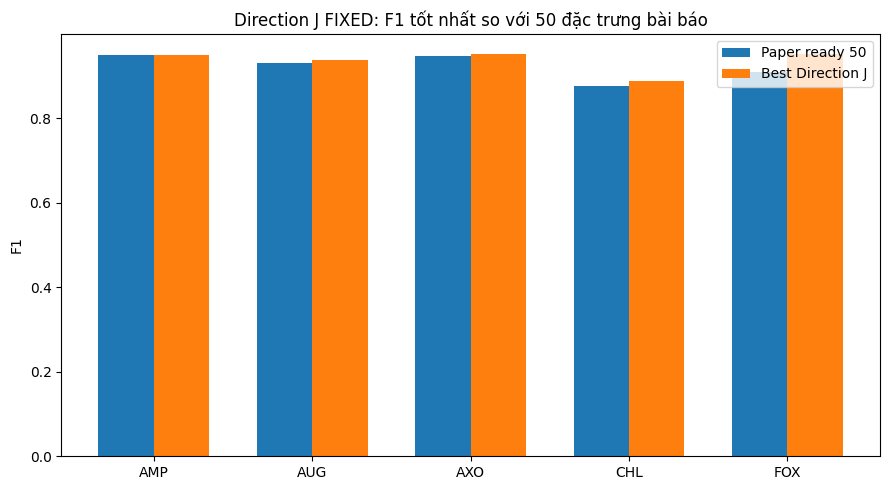

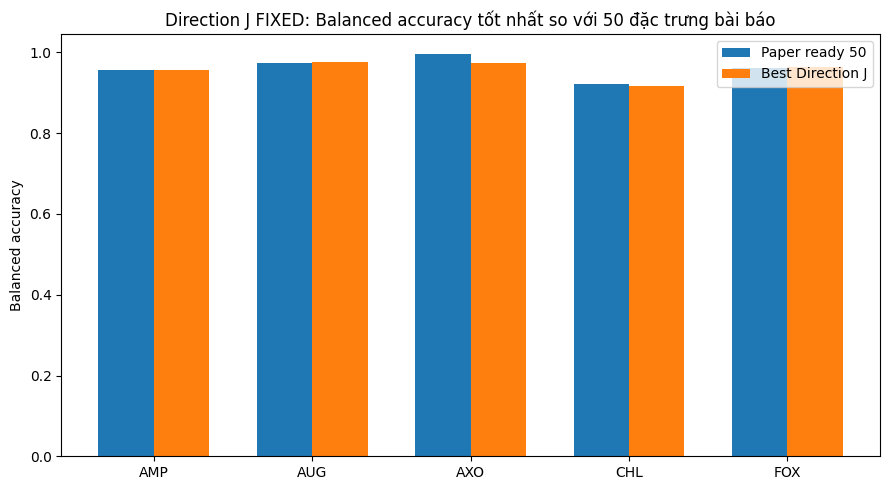

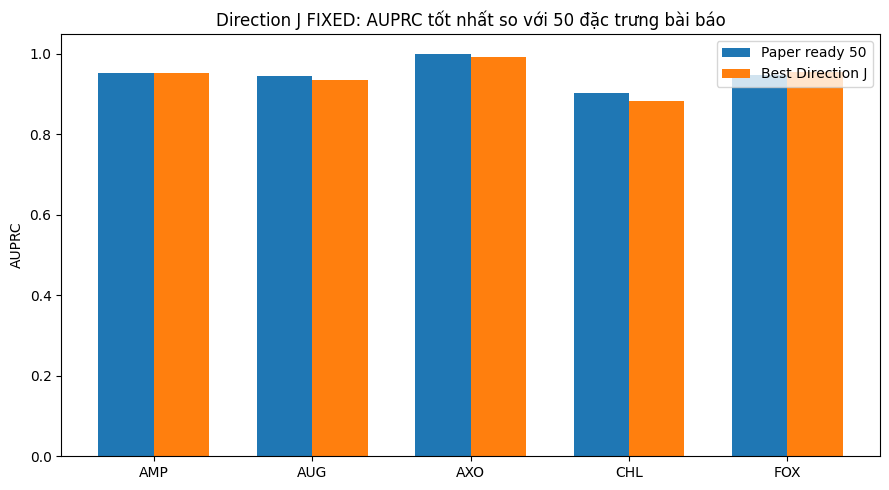

In [11]:

# =========================
# 10. Biểu đồ so sánh
# =========================

plot_df = comparison.copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["f1_mean_paper"], width, label="Paper ready 50")
plt.bar(x + width/2, plot_df["f1_mean_best"], width, label="Best Direction J")
plt.xticks(x, plot_df["drug"])
plt.ylabel("F1")
plt.title("Direction J FIXED: F1 tốt nhất so với 50 đặc trưng bài báo")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_J_FIXED_f1_vs_paper.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["balanced_accuracy_mean_paper"], width, label="Paper ready 50")
plt.bar(x + width/2, plot_df["balanced_accuracy_mean_best"], width, label="Best Direction J")
plt.xticks(x, plot_df["drug"])
plt.ylabel("Balanced accuracy")
plt.title("Direction J FIXED: Balanced accuracy tốt nhất so với 50 đặc trưng bài báo")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_J_FIXED_balacc_vs_paper.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["auprc_mean_paper"], width, label="Paper ready 50")
plt.bar(x + width/2, plot_df["auprc_mean_best"], width, label="Best Direction J")
plt.xticks(x, plot_df["drug"])
plt.ylabel("AUPRC")
plt.title("Direction J FIXED: AUPRC tốt nhất so với 50 đặc trưng bài báo")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_J_FIXED_auprc_vs_paper.png", dpi=200)
plt.show()


In [12]:

# =========================
# 11. Top feature được ensemble chọn
# =========================

feature_rows = []
for (drug, selector_name, k), counter in selected_feature_counters.items():
    total_runs = N_REPEATS
    for feat, count in counter.most_common(30):
        feature_rows.append({
            "drug": drug,
            "selector": selector_name,
            "k_features": k,
            "feature": feat,
            "selected_count": count,
            "selected_frequency": count / total_runs
        })

feature_stability_df = pd.DataFrame(feature_rows)
feature_stability_df.to_csv(OUTPUT_DIR / "direction_J_FIXED_top_selected_features.csv", index=False)

top_ensemble = feature_stability_df[
    (feature_stability_df["selector"] == "ensemble") &
    (feature_stability_df["k_features"] == 200)
].copy()

print("Top ensemble k=200 features:")
display(top_ensemble.groupby("drug").head(10))


Top ensemble k=200 features:


,drug,selector,k_features,feature,selected_count,selected_frequency
300,AMP,ensemble,200,FKE51_24750,3,1.0
301,AMP,ensemble,200,C3004_18245,3,1.0
302,AMP,ensemble,200,C3Z97_24385,3,1.0
303,AMP,ensemble,200,HF382_002470,3,1.0
304,AMP,ensemble,200,IHX02_004460,3,1.0
305,AMP,ensemble,200,CKP58_25195,3,1.0
306,AMP,ensemble,200,group_3068,3,1.0
307,AMP,ensemble,200,GXH05_18695,3,1.0
308,AMP,ensemble,200,M8C94_004791,3,1.0
309,AMP,ensemble,200,GXG79_15935,3,1.0


In [13]:

# =========================
# 12. Kết luận tự động
# =========================

lines = []
lines.append("# Direction J FIXED — Kết luận tự động")
lines.append("")
lines.append("## 1. Kiểm tra lỗi cũ")
lines.append("Bản fixed dùng đúng cặp gene.csv + DRUG_label.csv theo từng thuốc, nên baseline ready 50 phải quay lại mức hợp lý.")
lines.append("")
lines.append("## 2. Kết quả tốt nhất theo từng thuốc")

for _, row in best_df.iterrows():
    lines.append(
        f"- {row['drug']}: tốt nhất là {row['setting']} + {row['model']}, "
        f"F1 = {row['f1_mean']:.3f} ± {row['f1_std']:.3f}, "
        f"balanced accuracy = {row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}, "
        f"AUPRC = {row['auprc_mean']:.3f} ± {row['auprc_std']:.3f}."
    )

lines.append("")
lines.append("## 3. So sánh với 50 đặc trưng bài báo")
for _, row in comparison.iterrows():
    lines.append(
        f"- {row['drug']}: Direction J thay đổi F1 {row['delta_f1']:+.3f}, "
        f"balanced accuracy {row['delta_balanced_accuracy']:+.3f}, "
        f"AUPRC {row['delta_auprc']:+.3f} so với ready 50."
    )

lines.append("")
lines.append("## 4. Diễn giải")
lines.append("- Nếu Direction J tốt hơn ready 50 ở thuốc nào, ensemble pangenome feature selection có thể là hướng tăng hiệu năng cho thuốc đó.")
lines.append("- Nếu Direction J không tốt hơn ready 50, nghĩa là bộ 50 đặc trưng bài báo đã rất mạnh hoặc cần tối ưu thêm model/threshold/annotation.")
lines.append("- Kết quả này dùng để chọn chiến lược cuối theo từng thuốc thay vì dùng một cấu hình chung cho tất cả.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUTPUT_DIR / "AUTO_CONCLUSION_DIRECTION_J_FIXED.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)


# Direction J FIXED — Kết luận tự động

## 1. Kiểm tra lỗi cũ
Bản fixed dùng đúng cặp gene.csv + DRUG_label.csv theo từng thuốc, nên baseline ready 50 phải quay lại mức hợp lý.

## 2. Kết quả tốt nhất theo từng thuốc
- AMP: tốt nhất là ready_50_features_from_paper + XGB_weighted, F1 = 0.948 ± 0.023, balanced accuracy = 0.957 ± 0.019, AUPRC = 0.952 ± 0.027.
- AUG: tốt nhất là ensemble_top_50 + XGB_weighted, F1 = 0.936 ± 0.009, balanced accuracy = 0.976 ± 0.001, AUPRC = 0.934 ± 0.010.
- AXO: tốt nhất là chi2_top_200 + LR_balanced, F1 = 0.951 ± 0.025, balanced accuracy = 0.975 ± 0.040, AUPRC = 0.992 ± 0.010.
- CHL: tốt nhất là chi2_top_500 + LR_balanced, F1 = 0.887 ± 0.035, balanced accuracy = 0.917 ± 0.033, AUPRC = 0.884 ± 0.044.
- FOX: tốt nhất là ensemble_top_500 + XGB_weighted, F1 = 0.951 ± 0.020, balanced accuracy = 0.964 ± 0.001, AUPRC = 0.956 ± 0.010.

## 3. So sánh với 50 đặc trưng bài báo
- AMP: Direction J thay đổi F1 +0.000, balanced accuracy +0.000, AUPRC +0.000 so với ready 5

In [14]:

# =========================
# 13. Nén output
# =========================

zip_path = BASE_DIR / "salmonella_direction_J_FIXED_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("Đã lưu kết quả tại:", OUTPUT_DIR)
print("File zip:", zip_path)

# Nếu muốn tải về máy:
# from google.colab import files
# files.download(str(zip_path))


Đã lưu kết quả tại: /content/salmonella_direction_J_fixed/outputs
File zip: /content/salmonella_direction_J_fixed/salmonella_direction_J_FIXED_outputs.zip
